# Computer Vision Coursework Submission (IN3060)

**Student name, ID and cohort:** Merin Muhammad (220028896) - UG


# Notebook Setup
In this section you should include all the code cells required to test your coursework submission. Specifically:

### Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install mtcnn -q

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.6 MB/s eta 0:00:00


### Define Local Path

In the next cell you should assign to the variable `GOOGLE_DRIVE_PATH_AFTER_MYDRIVE` the relative path of this folder in your Google Drive.

**IMPORTANT:** you have to make sure that **all the files required to test your functions are loaded using this variable** (as was the case for all lab tutorials). In other words, do not use in the notebook any absolute paths. This will ensure that the markers can run your functions. Also, **do not use** the magic command `%cd` to change directory.



In [2]:
import os, sys

# TODO: Fill in the Google Drive path where you uploaded the CW_folder_UG
# Example: GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'Colab Notebooks/Computer Vision/CW_folder_UG'

GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'CW_Folder_UG'
GOOGLE_DRIVE_PATH = os.path.join('drive', 'My Drive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
print(os.listdir(GOOGLE_DRIVE_PATH))

CODE_DIR = os.path.join(GOOGLE_DRIVE_PATH, 'Code')
sys.path.insert(0, CODE_DIR)
MODELS_DIR = os.path.join(GOOGLE_DRIVE_PATH, 'Models')


['Models', 'CW_Dataset', 'Personal_Dataset', 'Code', 'CW_Dataset.zip', 'Personal_Dataset.zip', 'test_function.ipynb']


### Load packages

In the next cell you should load all the packages required to test your function.

In [3]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import models

from utils import *

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print('Device:', device)

Device: cpu


### Load models

In the next cell you should load your best performing model (this might consist of more than one file). Avoid to load it within `AgeDetection` to avoid having to reload it each time.

In [4]:
CLASS_NAMES = [AGE_LABELS[i] for i in range(4)]

def _build_resnet(n_classes=4):
    m = models.resnet18(weights=None)
    m.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(m.fc.in_features, n_classes))
    return m

model_ft = _build_resnet()
model_ft.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'model_3_finetune.pt'), map_location=device))
model_ft = model_ft.to(device); model_ft.eval()

print('Model loaded.')

Model loaded.


# Test AgeDetection

This section should allow to test the `AgeDetection` function. First, add cells with the code needed to load the necessary subroutines to make `AgeDetection` work.

In [5]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

_DATA_MEANS = np.array([0.485, 0.456, 0.406], dtype=np.float32)
_DATA_STDS  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
_IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

def _classify_crop(img_rgb, x, y, w, h):
    """Crop a face region from img_rgb (float [0,1] RGB) and return predicted class index."""
    face = img_rgb[y:y+h, x:x+w]
    if face.size == 0:
        face = img_rgb
    face = match_dataset_resolution(face)
    face = resize_image(face, (224, 224))
    t = torch.from_numpy(np.ascontiguousarray(
        np.transpose((face.astype(np.float32) - _DATA_MEANS) / _DATA_STDS, (2, 0, 1))
    )).unsqueeze(0).to(device)
    with torch.no_grad():
        return model_ft(t).argmax(1).item()

def AgeDetection(path_to_test):
    from pathlib import Path
    all_images = [p for p in Path(path_to_test).iterdir()
                  if p.suffix.lower() in _IMG_EXTS]
    paths = random.Random().sample(all_images, min(4, len(all_images)))

    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, p in zip(axes, paths):
        img_orig = read_rgb(str(p))
        boxes = get_all_face_boxes(img_orig)

        if not boxes:
            # No face detected. Classify whole image
            pred = _classify_crop(img_orig, 0, 0, img_orig.shape[1], img_orig.shape[0])
            ax.imshow(np.clip(img_orig, 0, 1))
            ax.set_title(os.path.basename(str(p)) + f'\nPred: {CLASS_NAMES[pred]}')
        else:
            ax.imshow(np.clip(img_orig, 0, 1))
            labels = []
            for bx, by, bw, bh in boxes:
                pred = _classify_crop(img_orig, bx, by, bw, bh)
                rect = mpatches.Rectangle(
                    (bx, by), bw, bh,
                    linewidth=2, edgecolor='red', facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(bx, max(by - 4, 0), CLASS_NAMES[pred],
                        color='white', fontsize=8, fontweight='bold',
                        bbox=dict(facecolor='red', alpha=0.8, pad=2, edgecolor='none'))
                labels.append(CLASS_NAMES[pred])
            ax.set_title(os.path.basename(str(p)) + '\n' + ', '.join(labels))

        ax.axis('off')

    plt.suptitle('ResNet18 Finetune on All Faces', fontsize=13)
    plt.tight_layout()
    plt.show()
    plt.close()

Then, make a call to the `AgeDetection` function to see what results it produces.

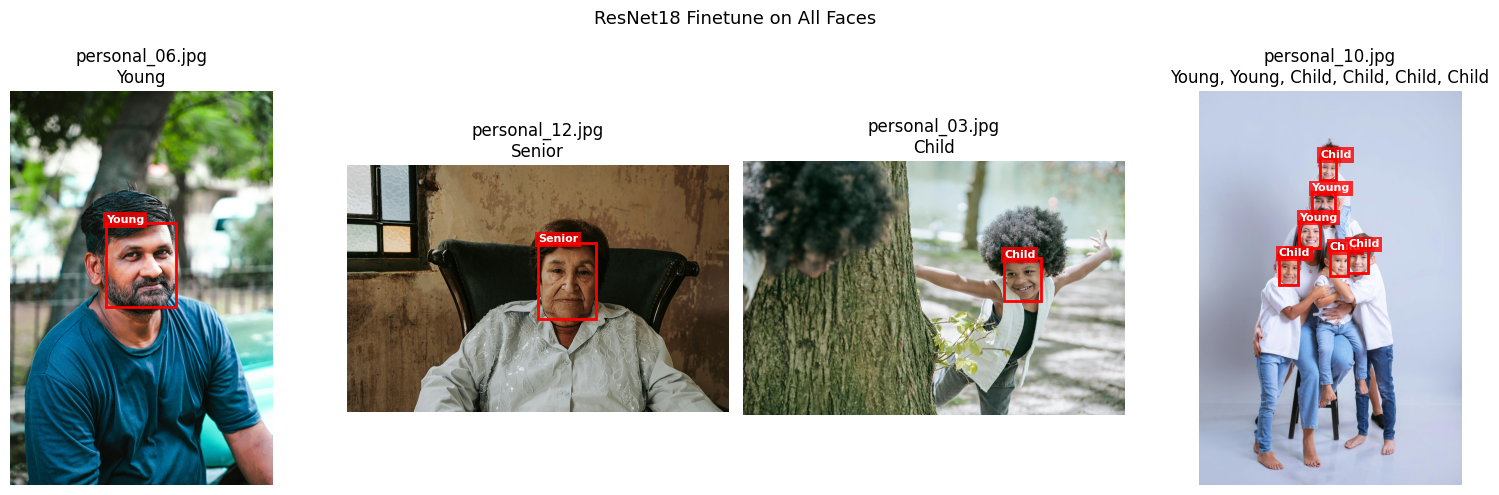

In [6]:
# Syntax for the next function is the following:
#
# AgeDetection(path_to_test)

path_to_test = os.path.join(GOOGLE_DRIVE_PATH, 'Personal_Dataset')
AgeDetection(path_to_test)